# Calculating Severity

## Setup

In [1]:
# Importing Needed Packages

!pip install anthropic
!pip install python-dotenv

import pandas as pd
import numpy as np
from dotenv import load_dotenv
from matplotlib import pyplot as plt
import seaborn as sns
import re
import time
from anthropic import Anthropic
from tqdm import tqdm
import os

  Using cached docstring_parser-0.18.0-py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.9 MB/s  0:00:00
Using cached docstring_parser-0.18.0-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [anthropic]/2 [anthropic]


## Understanding the Data

In [ ]:
# Reading in the csv file
data = pd.read_csv("02_Data_Cleaning/Raw_Input_Files/asrs_full.csv.gz")

FileNotFoundError: [Errno 2] No such file or directory: 'asrs_full.csv'

In [ ]:
data.head(4)

In [ ]:
# Displaying the first 20 rows of narrative text in full to get an intuition
with pd.option_context('display.max_colwidth', None,
                        'display.max_columns', None,
                        'display.max_rows', None,
                        'display.width', None):
    display(data.narrative_text.head(20))  # or print(df)

In [ ]:
# Creating a list of all words in the column so we can estimate how many tokens will be involved in NLP
full_text = data['narrative_text'].tolist()
single_text = ",".join(full_text)
single_text = single_text.replace(" ", ", ")
full_text = single_text.split(",")

In [ ]:
# Pulling the length of the list to estimate the task size
len(full_text)

****Deciding on a model****

The task is going to take 8.8 million tokens. Fable-5 has come out, and it costs $10/M Tokens. We are going to send it, to see how it goes. It should be fun. Otherwise Opus will be half the price. 

## Methodology

**Definitions**

ASRS is a NASA publication, and unfortunately, it does not apply any severity classifications to its data. Considering that these reports involve aviation incidents, we will look to the FAA for severity classifications

The current document outling USDOT FAA Safety Risk Management Policy is the 8040.4C: https://www.faa.gov/documentLibrary/media/Order/FAA_Order_8040.4C.pdf 

In Table C-1 it provides the following: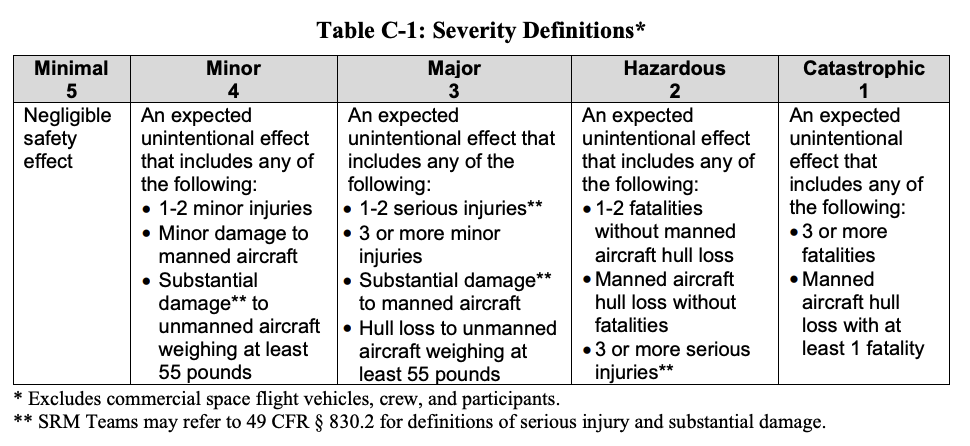


The definitions in this table rely on 49 CFR § 830.2: 
https://www.ecfr.gov/current/title-49/subtitle-B/chapter-VIII/part-830/subpart-A/section-830.2

Those definitions provide the following critera
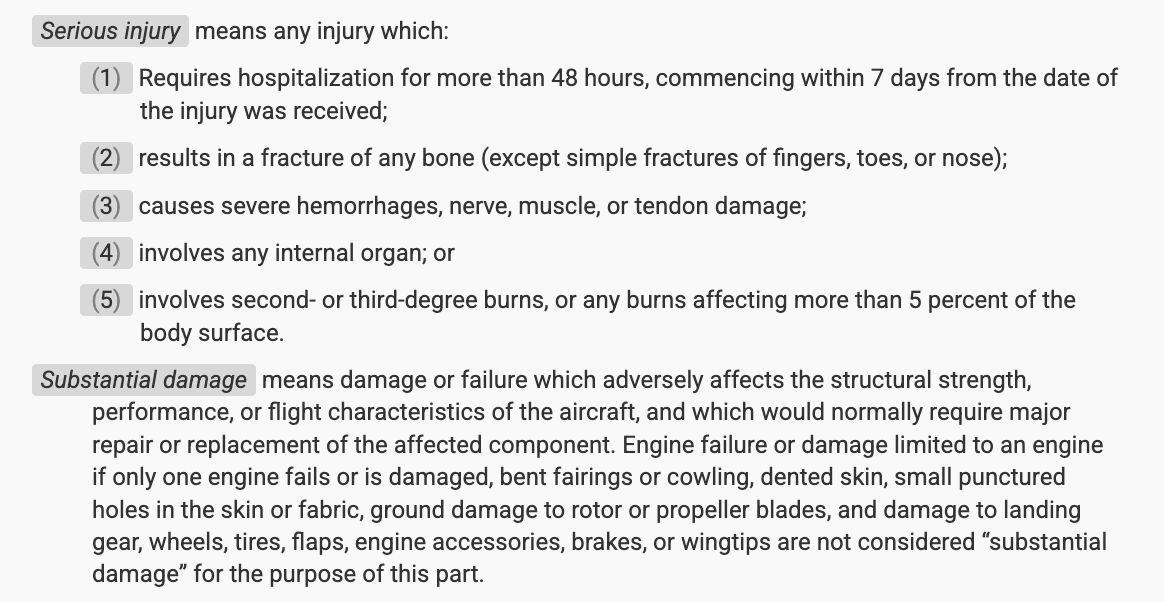

**Application**

We will use these defintions as context for the Fable-5 api call to classify the severity of each of the reports. But first we will test the accuracy on the first 20 or so

## Setting up the API Call

In [ ]:
load_dotenv("/home/jovyan/MSBA Mod 5/Team 3/API_keys.env")

In [ ]:
stop run = stop run - Do Not Commit to this Pipeline

In [ ]:
# ============================================================
# CONFIG
# ============================================================
CHECKPOINT_PATH = "02_Data_Cleaning/Output_Files/Data 6 - severity_scores.csv"
CHECKPOINT_EVERY = 100          # rows between checkpoint saves
MAX_RETRIES = 5
BASE_BACKOFF = 2                # seconds, doubles each retry

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
client = Anthropic(api_key=ANTHROPIC_API_KEY)  # reads ANTHROPIC_API_KEY from env var

In [ ]:
stop run = stop run - Do Not Commit to this Pipeline

In [ ]:
# ============================================================
# SYSTEM PROMPT
# ============================================================
system_prompt = """
Severity classification scale:
1 = Minimal — Negligible safety effect
2 = Minor — An expected unintentional effect that includes any of the following: 1-2 minor injuries, minor damage to manned aircraft, substantial damage** to unmanned aircraft weighing at least 55 pounds
3 = Major — An expected unintentional effect that includes any of the following: 1-2 serious injuries**, 3 or more minor injuries, substantial damage** to manned aircraft, hull loss to unmanned aircraft weighing at least 55 pounds
4 = Hazardous — An expected unintentional effect that includes any of the following: 1-2 fatalities without manned aircraft hull loss, manned aircraft hull loss without fatalities, 3 or more serious injuries**
5 = Catastrophic — An expected unintentional effect that includes any of the following: 3 or more fatalities, manned aircraft hull loss with at least 1 fatality

** Refer to 49 CFR § 830.2 for definitions of serious injury and substantial damage.

49 CFR § 830.2 Definitions:
Serious injury means any injury which: 

(1) Requires hospitalization for more than 48 hours, commencing within 7 days from the date of the injury was received; 

(2) results in a fracture of any bone (except simple fractures of fingers, toes, or nose); 

(3) causes severe hemorrhages, nerve, muscle, or tendon damage; 

(4) involves any internal organ; or 

(5) involves second- or third-degree burns, or any burns affecting more than 5 percent of the body surface.

Substantial damage means damage or failure which adversely affects the structural strength, performance, or flight characteristics of the aircraft, and 
which would normally require major repair or replacement of the affected component. Engine failure or damage limited to an engine if only one engine fails or is damaged, 
bent fairings or cowling, dented skin, small punctured holes in the skin or fabric, ground damage to rotor or propeller blades, and damage to landing gear, wheels, tires, flaps, 
engine accessories, brakes, or wingtips are not considered “substantial damage” for the purpose of this part.

---------------------

System Prompt:

Review the narrative text, and output three scores (self_score, actual_severity, potential_severity) in the format "{self_score},{actual_severity},{potential_severity}"

For each output score, adhere to the following instructions:

1) self_score

Review the narrative_text, and if the author of the text is implicated in the causal chain of the incident return the numeric value 1, otherwise return 0. In other words, if the person writing the report contributed somehow to the mistakes that led to the adverse incident described, return 1, else return 0.

Evaluation of the self-score should be made completely independently from any evaluation of severity. This evaluation should consider only whether or not the author describes their own contribution to the incident being reported.

If the narrative is too short, unclear, or nonsensical to classify, respond with "NA" instead.

Respond with ONLY a single digit (1 or 0) or "NA". Do not include any other text, punctuation, or explanation.


2) actual_severity

Based on the severity definitions above, classify this narrative's actual severity on a scale of 1-5.

Note that some of the severity definitions appeal to conditions that may not have been described in the narrative text.
For example, serious injury may be defined by the length and commencement of a hospital stay.
This information may not be contained in the narrative text - so, where injury is described, an appropriate amount of hospitalization should be assumed.
Fatalities should never be assumed as having occurred during the incident or following the incident unless the narrative text explicitly states there was a fatality or explicilty describes a necessarily mortal injury such as decapitation.
For example, if a narrative describes that a passenger or crew member suffered a heart attack, it can be assumed that there was an appropriate amount of hospitalization (2-5 days), but fatality should not be assumed unless the text states the heart attack led to death.

Actual severity should be considered the severity of the consequences that acutally materialized in reality according to the narrative. This is distinct from what could have potentially materialized had circumstances shifted slightly or have been left unmitigated.
For example, if a pilot notices they are on a mid-air collision course with another craft and successfully executes an evasive maneuver, the actual severity may be 1 (Minimal) considering that no real damage or injury occurred even though the potential severity may be 5 (Catastrophic) considering that multiple deaths could have occurred had the error not been corrected. 

If the narrative is too short, unclear, or nonsensical to classify, respond with "NA" instead.

Respond with ONLY a single digit (1-5) or "NA". Do not include any other text, punctuation, or explanation.

3) potential_severity

Based on the severity definitions above, classify this narrative's potential severity on a scale of 1-5.

Note that some of the severity definitions appeal to conditions that may not have been described in the narrative text.
For example, serious injury may be defined by the length and commencement of a hospital stay.
This information may not be contained in the narrative text - so, where injury is described, an appropriate amount of hospitalization should be assumed.
Fatalities should never be assumed as having occurred during the incident or following the incident unless the narrative text explicitly states there was a fatality or explicilty describes a necessarily mortal injury such as decapitation.
For example, if a narrative describes that a passenger or crew member suffered a heart attack, it can be assumed that there was an appropriate amount of hospitalization (2-5 days), but fatality should not be assumed unless the text states the heart attack led to death.

Potential severity should be considered the maximum reasonable severity considering the conditons described in the text if a single mitigating circumstance had not occurred or otherwise failed. This is distinct from actual severity, which should be considered the severity of the consequences that acutally materialized in reality according to the narrative.
For example, if a pilot notices they are on an imminent mid-air collision course with another craft and successfully executes an evasive maneuver, the actual severity may be 1 (Minimal) considering that no real damage or injury occurred, but the potential severity may be 5 (Catastrophic) considering that multiple deaths could have occurred had the error not been corrected or otherwise failed.
Note that evaluations of potential severity should consider how critical the mitigative circumstances are in avoiding the worst possible case, whether those mitigative circumstances are driven by corrective measures, routine preventative measures, or even pure chance.
Using the same example, if the text describes that the course correction occurred with a 30 miles between the crafts, rather than the the collision being imminent, this may not be considered catastrophic since a decent buffer implies opportunity for other forms of correction to occurr should the originally-described correction not have occurred or otherwise failed.
Similarly, consider if a report were to describe that two flights passed within 50 feet of each other, and the pilots only became aware of the other aircraft after it was too late to correct, and it was by chance alone the aircrafts missed each other. The mitigating circumstances here are pure chance that they missed each other, and this would be a potential severity of 5 (Catastrophic), even though the actual severity is 1 (Minimal).
Another example is that a plane with a failed front landing gear performing a successful emergency landing may have an actual severity of 3 (Major) or 4 (Hazardous), depending on whether the hull was lost, but the potential severity would be 5 (catastrophic) considering that multiple fatalities could have occurred had a single mitigative circumstance been different (pilot failed to execute perfect emergency landing).

If the narrative is too short, unclear, or nonsensical to classify, respond with "NA" instead.

Respond with ONLY a single digit (1-5) or "NA". Do not include any other text, punctuation, or explanation.

Again, response format is "{self_score},{potential_severity},{actual_severity}" - e.g. "1,3,5" or "0,NA,NA". Do not include any other text, punctuation, headers, or explanation.

"""


In [ ]:
stop run = stop run - Do Not Commit to this Pipeline

In [ ]:
# ============================================================
# DYNAMIC USER CONTENT (only the narrative changes)
# ============================================================
def build_prompt(narrative_text):
    return f"Narrative:\n{narrative_text}"

In [ ]:
stop run = stop run - Do Not Commit to this Pipeline

In [ ]:
# ============================================================
# PARSING
# ============================================================

def extract_text(response):
    for block in response.content:
        if block.type == "text":
            return block.text
    return ""

def parse_response(response_text):
    cleaned = response_text.strip().upper()
    parts = [p.strip() for p in cleaned.split(",")]

    if len(parts) != 3:
        return {"self_score": np.nan, "actual_severity": np.nan, "potential_severity": np.nan}

    def parse_field(value, valid_chars):
        if "NA" in value:
            return np.nan
        match = re.search(f'[{valid_chars}]', value)
        return int(match.group()) if match else np.nan

    return {
        "self_score": parse_field(parts[0], "01"),
        "actual_severity": parse_field(parts[1], "12345"),
        "potential_severity": parse_field(parts[2], "12345"),
    }

In [ ]:
stop run = stop run - Do Not Commit to this Pipeline

In [ ]:
# ============================================================
# API CALLS WITH RETRY
# ============================================================
def get_severity_scores(narrative_text, model = "claude-sonnet-5"):
    prompt = build_prompt(narrative_text)

    for attempt in range(MAX_RETRIES):
        try:
            response = client.messages.create(
                model=model,
                max_tokens=10,
                thinking={"type": "disabled"},
                system=[
                    {
                        "type": "text",
                        "text": system_prompt,
                        "cache_control": {"type" : "ephemeral"}
                    }
                ],
                messages=[{"role": "user", "content": build_prompt(narrative_text)}]
            )
            raw_text = response.content[0].text
            return parse_response(raw_text)

        except Exception as e:
            err_str = str(e)
            # Handle rate limit errors specifically
            if "rate_limit" in err_str.lower() or "429" in err_str:
                wait = BASE_BACKOFF * (2 ** attempt)
                print(f"Rate limited. Waiting {wait}s (attempt {attempt+1}/{MAX_RETRIES})...")
                time.sleep(wait)
            else:
                wait = BASE_BACKOFF * (2 ** attempt)
                print(f"Error: {err_str}. Retrying in {wait}s (attempt {attempt+1}/{MAX_RETRIES})...")
                time.sleep(wait)

    print("Max retries exceeded — logging as NaN.")
    return np.nan



In [ ]:
# ============================================================
# CHECKPOINT LOAD/SAVE
# ============================================================
def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
        completed_indices = set(checkpoint_df['index'])
        print(f"Resuming: {len(completed_indices)} rows already completed.")
        return checkpoint_df, completed_indices
    else:
        checkpoint_df = pd.DataFrame(columns=['index', 'self_score', 'actual_severity', 'potential_severity'])
        return checkpoint_df, set()

#def save_checkpoint(checkpoint_df):
    #checkpoint_df.to_csv(CHECKPOINT_PATH, index=False)

In [ ]:
# ============================================================
# MAIN LOOP
# ============================================================
def run_severity_pipeline(data, text_col='narrative_text', model="claude-sonnet-5", limit=None):
    checkpoint_df, completed_indices = load_checkpoint()
    results = checkpoint_df.to_dict('records')

    rows_to_process = data.index if limit is None else data.index[:limit]

    for count, idx in enumerate(rows_to_process):
        if idx in completed_indices:
            continue

        narrative = str(data.loc[idx, text_col])
        severity_scores = get_severity_scores(narrative, model=model)
        
        if not isinstance(severity_scores, dict):
            severity_scores = {"self_score": np.nan, "actual_severity": np.nan, "potential_severity": np.nan}
        
        results.append({
            'index': idx,
            'self_score': severity_scores['self_score'],
            'actual_severity': severity_scores['actual_severity'],
            'potential_severity': severity_scores['potential_severity']
        })

        if (count + 1) % CHECKPOINT_EVERY == 0:
            checkpoint_df = pd.DataFrame(results)
            save_checkpoint(checkpoint_df)
            print(f"Checkpoint saved at row {count + 1}")

    # final save
    checkpoint_df = pd.DataFrame(results)
    save_checkpoint(checkpoint_df)
    print("Run complete.")
    return checkpoint_df


In [ ]:
# ============================================================
# MERGE BACK INTO MAIN DATAFRAME
# ============================================================
def merge_severity_into_data(data, checkpoint_df):
    checkpoint_indexed = checkpoint_df.set_index('index')
    data['self_score'] = data.index.map(checkpoint_indexed['self_score'])
    data['actual_severity'] = data.index.map(checkpoint_indexed['actual_severity'])
    data['potential_severity'] = data.index.map(checkpoint_indexed['potential_severity'])
    return data

## Testing the API Call

In [ ]:
test_results = run_severity_pipeline(data, text_col='narrative_text', limit=25)
test_results

In [ ]:
for idx in data.index[:25]:
    print(f"--- Row {idx} ---")
    print(data.loc[idx, 'narrative_text'])
    print()

In [ ]:
opus_test_results = run_severity_pipeline(data, text_col='narrative_text', model = 'claude-opus-4-8', limit=25)
opus_test_results

In [ ]:
sonnet_test2_results = run_severity_pipeline(data, text_col='narrative_text', limit=25)
sonnet_test2_results

In [ ]:
opus_test2_results = run_severity_pipeline(data, text_col='narrative_text', model = 'claude-opus-4-8', limit=25)
opus_test2_results

In [ ]:
# Going to dcide to go with the Sonnet Model

## Running the Full Analysis

In [ ]:
full_results = run_severity_pipeline(data, text_col='narrative_text', limit=None)
full_results